In [1]:
import pandas as pd
import json
from globals import BASE_DIR, available_datasets, top_k_eval, valid_popularity, recommendation_dirpart
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import math
from postprocess_baseline_top_k import dataset_metadata
from evaluation_metrics import ndcg, calculate_arp_poplift, evaluation_user_group_means, jensen_shannon
import pingouin as pg


dataset = "gowalla" # perform for each dataset individually

len(available_datasets) # make sure the available datasets are correct since this affects the Bonferroni correction of the t-tests

3

In [2]:
def process_top_k_json(input_file, output_file, k=10):
    """
    Process top-k recommendations from a JSON file, keeping only the item IDs for each user.
    """
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    try:
        with open(input_file, "r") as infile:
            data = json.load(infile)

        top_k_result = {}
        for user_id, recommendations in data.items():
            if recommendations and isinstance(recommendations[0], dict):
                item_ids = recommendations[0]["item_id"][:k]
                top_k_result[user_id] = item_ids

        with open(output_file, "w") as outfile:
            json.dump(top_k_result, outfile, indent=4)
        print(f"Processed file saved to: {output_file}")
    
    except Exception as e:
        print(f"Error processing {input_file}: {e}")

In [3]:
def create_model_directories(dataset, data, base_dir, recommendation_dirpart):
    """
    Create output directories
    """
    model_directories = {}
    methods = ["baseline", "cp", "cp_min_js"]

    def recommender_dir_combiner(dataset, modelpart, method):
        return os.path.join(base_dir, f"{dataset}_dataset", recommendation_dirpart, modelpart, method, "top_k_recommendations.json")

    for result in data:
        model_name = result["model"]
        model_directories[model_name] = {}
        
        for method in methods:
            model_directories[model_name][method] = recommender_dir_combiner(dataset, result["directory"], method)
    
    return model_directories

def open_ground_truth_user_group(dataset, valid_popularity=valid_popularity):
    """Perform data splitting and user group creation."""

    train_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.train.inter"), sep="\t")
    test_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.test.inter"), sep="\t")
    valid_data = pd.read_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "processed_data_recbole", f"{dataset}_sample.valid.inter"), sep="\t")

    print("Train data, test data and valid data shapes:")
    print(train_data.shape, test_data.shape, valid_data.shape)
    train_data = pd.concat([train_data, valid_data])
    user_group_dir = os.path.join(BASE_DIR, f"{dataset}_dataset", f"{dataset}_user_id_popularity.json")
    with open(user_group_dir) as f:
        user_groups = json.load(f)

    user_groups["HighPop"] = user_groups.pop("high")
    user_groups["LowPop"] = user_groups.pop("low")
    user_groups["MedPop"] = user_groups.pop("medium")



    checkin_df = train_data.copy()
    
    # Calculate item popularity
    value_counts = checkin_df["item_id:token"].value_counts().reset_index()
    value_counts.columns = ["item_id:token", "count"]
    value_counts[valid_popularity] = value_counts["count"] / len(value_counts)
    checkin_df = checkin_df.merge(
        value_counts[["item_id:token", valid_popularity]],
        on="item_id:token",
        how="left",
    )
    checkin_df.sort_values(by=valid_popularity, ascending=False, inplace=True)
    item_popularity = checkin_df.drop_duplicates(subset="item_id:token", keep="first")[
        ["item_id:token", valid_popularity]
    ]

    h_group = item_popularity.head(int(len(item_popularity) * 0.2))
    h_group["item_pop_group"] = "h"
    t_group = item_popularity.tail(int(len(item_popularity) * 0.2))
    t_group["item_pop_group"] = "t"
    m_group = item_popularity[
        ~item_popularity["item_id:token"].isin(h_group["item_id:token"]) &
        ~item_popularity["item_id:token"].isin(t_group["item_id:token"])
    ]
    m_group["item_pop_group"] = "m"

    item_popularity = pd.concat([h_group, m_group, t_group])
    item_popularity.sort_values(by=valid_popularity, inplace=True, ascending=False)

    upts = checkin_df.groupby("user_id:token")[valid_popularity].mean().reset_index()
    upts.columns = ["user_id:token", "upts"]
    return train_data, test_data, user_groups, item_popularity, upts


In [4]:
data = dataset_metadata(dataset, recommendation_dirpart)

In [5]:
data

[{'directory': 'gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00',
  'dataset': 'gowalla_sample',
  'model_type': 'contextpoi',
  'model': 'LORE',
  'date': 'Sep-16-2024_09-00-00'},
 {'directory': 'gowalla_sample-BPR-Dec-19-2024_20-23-30',
  'dataset': 'gowalla_sample',
  'model_type': 'general',
  'model': 'BPR',
  'date': 'Dec-19-2024_20-23-30'},
 {'directory': 'gowalla_sample-contextpoi-USG-Sep-16-2024_09-00-00',
  'dataset': 'gowalla_sample',
  'model_type': 'contextpoi',
  'model': 'USG',
  'date': 'Sep-16-2024_09-00-00'}]

In [6]:
model_dirs = create_model_directories(dataset, data, BASE_DIR, recommendation_dirpart)

In [7]:
model_dirs

{'LORE': {'baseline': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/baseline/top_k_recommendations.json',
  'cp': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/cp/top_k_recommendations.json',
  'cp_min_js': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/cp_min_js/top_k_recommendations.json'},
 'BPR': {'baseline': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-BPR-Dec-19-2024_20-23-30/baseline/top_k_recommendations.json',
  'cp': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-BPR-Dec-19-2024_20-23-30/cp/top_k_recommendations.json',
  'cp_min_js': '/home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowal

In [8]:
def unstack_recommendations(df):
    """Unstack the recommendations for each user into separate rows."""
    unstacked_df = df.explode(["item_id:token"]).reset_index(drop=True)
    return unstacked_df

In [9]:
def top_k_to_df(recommender_dir, top_k_eval=10):
    """ Fixed version that handles nested lists """
    with open(recommender_dir) as f:
        data = json.load(f)
    
    base_recommendations = []
    
    for user, items in data.items():
        # FIX: Check if items is nested [[...]]
        if isinstance(items, list) and len(items) > 0 and isinstance(items[0], list):
            # Flatten: items = [[...]] -> items = [...]
            items = items[0]
        
        # Now iterate through individual items
        for item in items:
            base_recommendations.append({
                "user_id:token": user,
                "item_id:token": item
            })
    
    base_df = pd.DataFrame(base_recommendations)
    base_df = unstack_recommendations(base_df)
    df = base_df.groupby("user_id:token").head(top_k_eval)
    
    return df

In [10]:
train_data, test_data, user_groups, item_popularity, upts = open_ground_truth_user_group(dataset)
user_groups["All"] = user_groups["HighPop"] + user_groups["MedPop"] + user_groups["LowPop"]

Train data, test data and valid data shapes:
(34177, 3) (11328, 3) (8174, 3)


/tmp/ipykernel_50824/1289660354.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h_group["item_pop_group"] = "h"
/tmp/ipykernel_50824/1289660354.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_group["item_pop_group"] = "t"
/tmp/ipykernel_50824/1289660354.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

In [32]:
test_data

,user_id:token,item_id:token,checkin_count:float
0,0_x,5889_x,1
1,0_x,3932_x,1
2,0_x,6085_x,8
3,0_x,6122_x,1
4,0_x,6589_x,5
...,...,...,...
11323,9_x,747_x,1
11324,9_x,369_x,2
11325,9_x,2483_x,1
11326,9_x,4085_x,1


In [11]:
def create_pop_distributions(data):
    """Create a DataFrame with the distribution of item popularity for different user groups."""
    data = data.merge(item_popularity, on="item_id:token", how="left")
    g1 = data.loc[data["user_id:token"].isin(user_groups["HighPop"])].value_counts("item_pop_group", normalize=True).rename("g1")
    g2 = data.loc[data["user_id:token"].isin(user_groups["MedPop"])].value_counts("item_pop_group", normalize=True).rename("g2")
    g3 = data.loc[data["user_id:token"].isin(user_groups["LowPop"])].value_counts("item_pop_group", normalize=True).rename("g3")
    all = data.value_counts("item_pop_group", normalize=True).rename("all")
    distr_df = pd.DataFrame([g1, g2, g3, all]).fillna(0)
    distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True)
    return distr_df


ground_truth_distr = create_pop_distributions(train_data)

In [12]:
ground_truth_distr

item_pop_group,h,m,t
HighPop,0.760177,0.212192,0.027631
MedPop,0.515712,0.434035,0.050253
LowPop,0.452118,0.504092,0.043790
All,0.532620,0.420722,0.046658


In [13]:
def preprocess_distr(distr_df):
    """Preprocess the distribution DataFrame for plotting."""
    #distr_df.rename(index={"g1":"HighPop", "g2":"MedPop", "g3":"LowPop", "all":"All"}, inplace=True) # COMMENT IN FOR CALCULATING RESULTS, COMMENT OUT FOR PLOTTING
    data = distr_df.to_dict()
    result = []
    user_groups = data["h"].keys()

    for group in user_groups:
        h_value = data.get("h", {}).get(group, 0)
        m_value = data.get("m", {}).get(group, 0)
        t_value = data.get("t", {}).get(group, 0)
        
        result.append({
            "user_group": group,
            "h_ratio": h_value,
            "m_ratio": m_value,
            "t_ratio": t_value
        })

    return result


In [14]:
# Function for plotting popularity distribution (no legend inside this function)
def plot_popularity_distribution(ax, distr_df, label):
    """ Plot the popularity distribution of items for different user groups."""
    desired_order = ["LowPop", "MedPop", "HighPop", "All"]
    distr_df = distr_df.reindex(desired_order)
    colors = plt.cm.viridis([0.1, 0.5, 0.9])
    bars = distr_df.plot(kind="bar", stacked=True, ax=ax, color=colors, legend=False, edgecolor="black", linewidth=0, width=0.6)
    if label is not None:
        ax.set_title(f"{label}", fontsize=10)
    ax.set_xlabel("User Groups")
    return distr_df

def plot_line_chart(results, model_name, ax, metric):
    """
    Plot scores (nDCG, ARP, PopLift) as line plots for each user group, comparing methods.
    """
    methods = ["baseline", "cp", "cp_min_js"]
    user_groups = ["HighPop", "MedPop", "LowPop", "All"]
    group_labels = ["HighPop", "MedPop", "LowPop", "All"]

    metric_values = {
        method: [results[model_name][method][group][f"{metric}"] for group in user_groups]
        for method in methods
    }

    metric_transposed = list(zip(*metric_values.values()))  # Group-wise scores across methods

    # Plot each user group"s metric scores as a line plot
    colors = plt.cm.viridis([0.1, 0.5, 0.9, 0.3])
    for idx, group_label in enumerate(group_labels):
        ax.plot(methods, metric_transposed[idx], marker="o", label=group_label, color=colors[idx])

    ax.set_ylabel(f"{metric.upper()} Score", fontsize=12)
    ax.grid(True)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=16)




In [15]:
def calculate_t_test_between_user_groups(group_scores):
    """ Calculate t-test for two-sample t-test between low and high groups. 
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""
    
    ttest = {}
    # Conducting two-sample ttest
    result_low_high = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["HighPop"].values()),
                    correction=True)
    
    result_low_med = pg.ttest(list(group_scores["LowPop"].values()), 
                    list(group_scores["MedPop"].values()),
                    correction=True)
    
    ttest["low_high"] = float(result_low_high["p-val"])
    ttest["low_medium"] = float(result_low_med["p-val"])

    return ttest


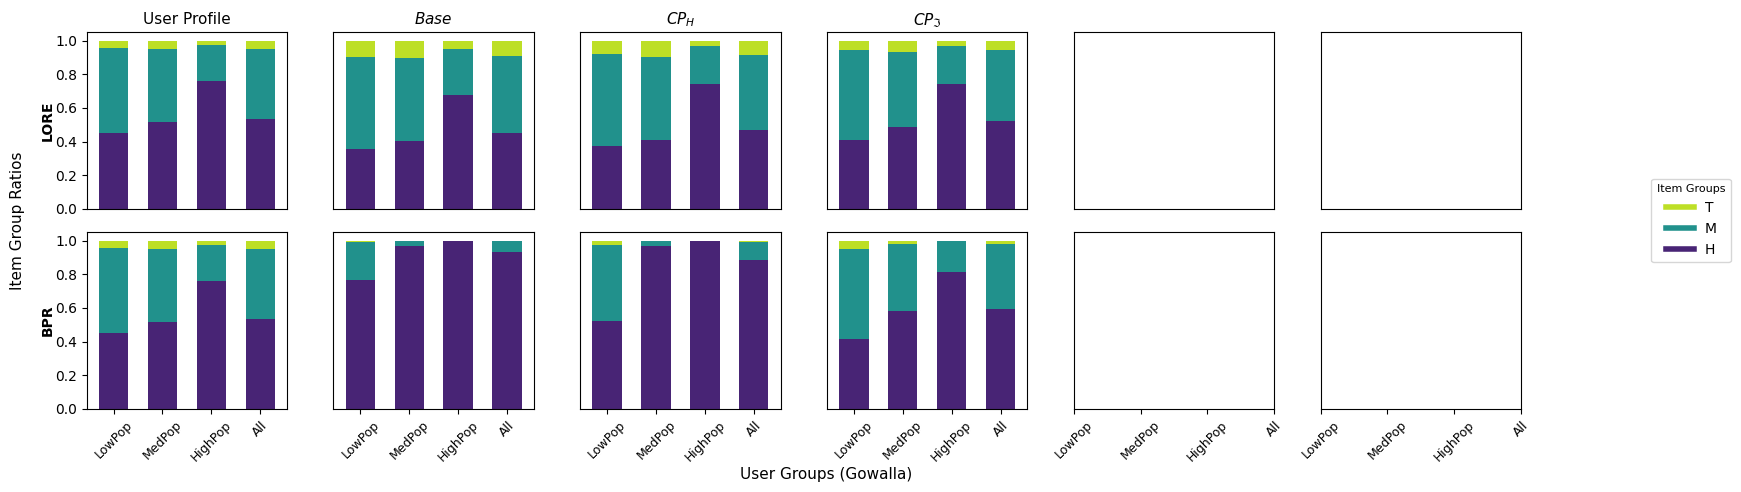

In [16]:
""" Looping through the models and methods to plot the popularity distribution """
fig, axs = plt.subplots(2, 6, figsize=(16, 5.5))  # 3 models x 4 methods
method_names_for_title = ["$Base$", "$CP_H$", "$CP_\Im$", "Borda", "Plurality"]

# model_dirs_plot = copy.deepcopy(model_dirs)
filtered_models = [
    (model_name, methods)
    for model_name, methods in model_dirs.items()
    if model_name not in ["SimpleX", "USG", "plurality", "borda"]
]

for i, (model_name, methods) in enumerate(filtered_models):
    # print(model_name)   
    ax = axs[i, 0]
    plot_popularity_distribution(ax, ground_truth_distr, None)  # no title here
    if i == 0:
        ax.set_title("User Profile", fontsize=11)

    for j, (method_name, json_file) in enumerate(methods.items()):
        # print(method_name, json_file)
        df = top_k_to_df(json_file)
        distr_df = create_pop_distributions(df)

        ax = axs[i, j + 1]
        plot_popularity_distribution(ax, distr_df, None)  # no title here
        if i == 0:
            ax.set_title(method_names_for_title[j], fontsize=11)


    axs[i, 0].set_ylabel(model_name, fontsize=10, weight="bold", labelpad=0)

    if i == 5:
                for k in range(6):
                    axs[i, k].set_xticks(range(6))
                    axs[i, k].set_xlabel("User Groups")
    else:
        for k in range(6):
            axs[i, k].set_xlabel("")

for ax in axs[-1, :]:
    ax.set_xticks(range(4))
    ax.set_xticklabels(["LowPop", "MedPop", "HighPop", "All"], rotation=45, fontsize=9)

for row in axs[:-1, :]:
    for ax in row:
        ax.set_xticks([])

for row in axs:
    for ax in row[1:]:
        ax.set_yticks([])


fig.text(0.55, 0.03, f"User Groups ({dataset.capitalize()})", ha="center", fontsize=11)
fig.text(0.04, 0.5, "Item Group Ratios", va="center", rotation="vertical", fontsize=11)

handles = [plt.Line2D([0], [0], color=color, lw=4) for color in plt.cm.viridis([0.9, 0.5, 0.1])]
labels = ["T", "M", "H"]


fig.legend(handles, labels, title="Item Groups", loc="center right", bbox_to_anchor=(1.12, 0.5), ncol=1, title_fontsize=8)
#fig.suptitle(f"Popularity Distribution for {dataset.capitalize()} Dataset", fontsize=12, weight="bold", y=0.87, x=0.57)
plt.tight_layout(rect=[0.05, 0.03, 1, 0.91])
# plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", "popularity_distribution_paper.png"), bbox_inches="tight")


In [17]:
""" Looping through the models and methods to store and process the results """
group_scores_ndcg = {}
group_scores_arp = {}
group_scores_poplift = {}
results = {}
ttest_results = {}

distr_dict_ground_truth = preprocess_distr(ground_truth_distr)

for i, (model_name, methods) in enumerate(model_dirs.items()):
    if model_name not in ["SimpleX", "USG", "plurality", "borda"]:
        results[model_name] = {}
        ttest_results[model_name] = {}

        group_scores_ndcg[model_name] = {}
        group_scores_arp[model_name] = {}
        group_scores_poplift[model_name] = {}

        for j, (method_name, json_file) in enumerate(methods.items()):

            ttest_results[model_name][method_name] = {}
  
            df = top_k_to_df(json_file)

            print(f"\n=== {model_name} / {method_name} ===")
            print(f"df user_id type: {df['user_id:token'].dtype}, sample: {df['user_id:token'].iloc[:3].tolist()}")
            print(f"test_data user_id type: {test_data['user_id:token'].dtype}, sample: {test_data['user_id:token'].iloc[:3].tolist()}")
            rec_items = set(df["item_id:token"].unique())
            test_items = set(test_data["item_id:token"].unique())
            print(f"Rec items: {len(rec_items)}, Test items: {len(test_items)}, Overlap: {len(rec_items & test_items)}")
            # Check overlap
            rec_users = set(df["user_id:token"].unique())
            test_users = set(test_data["user_id:token"].unique())
            print(f"Rec users: {len(rec_users)}, Test users: {len(test_users)}, Overlap: {len(rec_users & test_users)}")

            ndcg_scores = ndcg(df=df, test_data=test_data, top_k_eval=top_k_eval)
            df_with_item_pop = df.merge(item_popularity, on="item_id:token", how="left")
            arp_scores, poplift_scores = calculate_arp_poplift(df_with_item_pop, item_popularity, upts, valid_popularity)
            distr_df = create_pop_distributions(df)
            distr_dict_recs = preprocess_distr(distr_df)

            


            jsd_group = {}
            for group_gt, group_recs in zip(distr_dict_ground_truth, distr_dict_recs):
                jsd_group[group_gt["user_group"]] = jensen_shannon(group_gt, group_recs)

            group_eval, group_ndcg_scores, group_arp_scores, group_poplift_scores = evaluation_user_group_means(ndcg_scores, arp_scores, poplift_scores, user_groups, df)

            group_scores_ndcg[model_name][method_name] = group_ndcg_scores
            group_scores_arp[model_name][method_name] = group_arp_scores
            group_scores_poplift[model_name][method_name] = group_poplift_scores

            # ttests between low and high / low and medium to check whether LowPop users are disadvantaged
            # ttest_results[model_name][method_name]["ndcg"] = calculate_t_test_between_user_groups(group_ndcg_scores)
            # ttest_results[model_name][method_name]["arp"] = calculate_t_test_between_user_groups(group_arp_scores)
            # ttest_results[model_name][method_name]["poplift"] = calculate_t_test_between_user_groups(group_poplift_scores)
        
            for group_name, jsd_value in jsd_group.items():
                if group_name in group_eval:
                    group_eval[group_name]["js"] = jsd_value
                else:
                    # In case the group exists in jsd_group but not in group_eval
                    group_eval[group_name] = {"js": jsd_value}

            results[model_name][method_name] = group_eval


=== LORE / baseline ===
df user_id type: object, sample: ['170_x', '170_x', '170_x']
test_data user_id type: object, sample: ['0_x', '0_x', '0_x']
Rec items: 4943, Test items: 4937, Overlap: 3300
Rec users: 1500, Test users: 1500, Overlap: 1500

=== LORE / cp ===
df user_id type: object, sample: ['0_x', '0_x', '0_x']
test_data user_id type: object, sample: ['0_x', '0_x', '0_x']
Rec items: 4888, Test items: 4937, Overlap: 3238
Rec users: 1500, Test users: 1500, Overlap: 1500

=== LORE / cp_min_js ===
df user_id type: object, sample: ['0_x', '0_x', '0_x']
test_data user_id type: object, sample: ['0_x', '0_x', '0_x']
Rec items: 4698, Test items: 4937, Overlap: 3146
Rec users: 1500, Test users: 1500, Overlap: 1500

=== BPR / baseline ===
df user_id type: object, sample: ['859_x', '859_x', '859_x']
test_data user_id type: object, sample: ['0_x', '0_x', '0_x']
Rec items: 1051, Test items: 4937, Overlap: 847
Rec users: 1500, Test users: 1500, Overlap: 1500

=== BPR / cp ===
df user_id type: 

In [34]:
with open(model_dirs["BPR"]["baseline"]) as f:
    raw_baseline = json.load(f)

with open(model_dirs["BPR"]["cp"]) as f:
    raw_cp = json.load(f)

print("Baseline first 3 keys:", list(raw_baseline.keys())[:3])
print("CP first 3 keys:", list(raw_cp.keys())[:3])
print("Baseline total users:", len(raw_baseline))
print("CP total users:", len(raw_cp))

# Check if baseline has the nested [[...]] structure vs cp
first_key = list(raw_baseline.keys())[0]
print("\nBaseline value type:", type(raw_baseline[first_key]))
print("Baseline value sample:", str(raw_baseline[first_key])[:200])

first_key_cp = list(raw_cp.keys())[0]
print("\nCP value type:", type(raw_cp[first_key_cp]))
print("CP value sample:", str(raw_cp[first_key_cp])[:200])

Baseline first 3 keys: ['859_x', '875_x', '1358_x']
CP first 3 keys: ['0_x', '1000_x', '1001_x']
Baseline total users: 1500
CP total users: 1500

Baseline value type: <class 'list'>
Baseline value sample: [['10_x', '0_x', '73_x', '202_x', '12_x', '8_x', '1_x', '118_x', '4_x', '427_x', '414_x', '2933_x', '418_x', '17_x', '15_x', '4975_x', '905_x', '3131_x', '16_x', '2141_x', '3749_x', '199_x', '1183_x',

CP value type: <class 'list'>
CP value sample: ['63_x', '964_x', '1857_x', '5169_x', '392_x', '915_x', '118_x', '2320_x', '57_x', '369_x']


In [38]:
baseline_keys = set(raw_baseline.keys())
cp_keys = set(raw_cp.keys())

print(f"Baseline keys: {len(baseline_keys)}")
print(f"CP keys: {len(cp_keys)}")
print(f"Overlap: {len(baseline_keys & cp_keys)}")
print(f"In baseline but not CP: {sorted(baseline_keys - cp_keys)[:10]}")
print(f"In CP but not baseline: {sorted(cp_keys - baseline_keys)[:10]}")

Baseline keys: 1500
CP keys: 1500
Overlap: 1500
In baseline but not CP: []
In CP but not baseline: []


In [19]:
results

{'LORE': {'baseline': {'HighPop': {'ndcg': 0.050997701611666085,
    'arp': 0.005026913178107532,
    'poplift': -0.14067751966456585,
    'gini': 0.5230586811857221,
    'js': 0.007055016131192693},
   'LowPop': {'ndcg': 0.07145459066645042,
    'arp': 0.0010477055793966766,
    'poplift': 0.009040964199245943,
    'gini': 0.39286293937248895,
    'js': 0.012005741484899385},
   'MedPop': {'ndcg': 0.036940085325353075,
    'arp': 0.002065217373091511,
    'poplift': 0.0606030545501211,
    'gini': 0.3999162262006374,
    'js': 0.012697372047307318},
   'All': {'ndcg': 0.04665450965083514,
    'arp': 0.002454054175355751,
    'poplift': 0.010034521637008674,
    'gini': 0.4491252006203992,
    'js': 0.00830399371045442}},
  'cp': {'HighPop': {'ndcg': 0.05436961585288614,
    'arp': 0.005114142236699238,
    'poplift': -0.1284420219044514,
    'gini': 0.5388389303482575,
    'js': 0.0004231989529764361},
   'LowPop': {'ndcg': 0.07085306171408892,
    'arp': 0.001072566051393412,
    'po

In [20]:
def t_tests_rq1(metric_scores, model_1="BPR", other_models=["LORE", "USG"]):
    """ Perform t-tests between algorithms/methods to answer RQ1 (Compare Individual Effects of Context-Aware Recommendation and CP to general Baseline)
    Source t-test: https://www.geeksforgeeks.org/how-to-conduct-a-two-sample-t-test-in-python/"""

    ttest_results = {}

    # Compare to other models (LORE, USG)
    for other_model in other_models:
        ttest_results[other_model] = {}
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline_1 = metric_scores.get(model_1, {}).get("baseline", {}).get(group, {})
            baseline_2 = metric_scores.get(other_model, {}).get("baseline", {}).get(group, {})

            common_users = set(baseline_1.keys()) & set(baseline_2.keys())

            if common_users:
                vals_1 = [baseline_1[u] for u in common_users]
                vals_2 = [baseline_2[u] for u in common_users]

                test = pg.ttest(vals_1, vals_2, paired=True, correction=True)
                delta = np.mean(vals_2) - np.mean(vals_1)

                ttest_results[other_model][group] = {
                    "p_val": float(test["p-val"].values[0]),
                    "delta": float(delta),
                }
            else:
                ttest_results[other_model][group] = {
                    "p_val": None,
                    "delta": None,
                }

    # Compare BPR baseline to its own variants
    for variant in ["cp", "cp_min_js"]:
        ttest_results[variant] = {}
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline = metric_scores.get(model_1, {}).get("baseline", {}).get(group, {})
            variant_scores = metric_scores.get(model_1, {}).get(variant, {}).get(group, {})

            common_users = set(baseline.keys()) & set(variant_scores.keys())

            if common_users:
                vals_base = [baseline[u] for u in common_users]
                vals_variant = [variant_scores[u] for u in common_users]

                test = pg.ttest(vals_base, vals_variant, paired=True, correction=True)
                delta = np.mean(vals_variant) - np.mean(vals_base)

                ttest_results[variant][group] = {
                    "p_val": float(test["p-val"].values[0]),
                    "delta": float(delta),
                }
            else:
                ttest_results[variant][group] = {
                    "p_val": None,
                    "delta": None,
                }

    return ttest_results


In [21]:
def diagnose_cp_effectiveness(model_dirs, top_k_eval=10):
    """Check if CP is actually reranking items OR if it's not being applied at all"""
    
    print("=" * 80)
    print(f"DIAGNOSIS: Are CP JSON files actually different from baseline?")
    print("=" * 80)
    
    for model_name, methods in model_dirs.items():
        if model_name in ["SimpleX", "USG", "plurality", "borda"]:
            continue
            
        print(f"\n{'='*80}")
        print(f"MODEL: {model_name}")
        print('='*80)
        
        baseline_file = methods.get("baseline")
        cp_file = methods.get("cp_min_js")
        #cp_min_js_file = methods.get("cp_min_js")
        
        if not all([baseline_file, cp_file]):
            print("  ⚠️  Missing files")
            continue
        
        # Load JSONs
        with open(baseline_file) as f:
            baseline_data = json.load(f)
        with open(cp_file) as f:
            cp_data = json.load(f)
        
        # Get all users
        all_users = set(baseline_data.keys()) & set(cp_data.keys())
        
        if not all_users:
            print("  ⚠️  No common users!")
            continue
        
        # Check multiple aspects
        identical_full_lists = 0
        identical_top10 = 0
        identical_top3 = 0
        any_difference = 0
        
        sample_size = min(20, len(all_users))
        sample_users = list(all_users)[:sample_size]
        
        for user in sample_users:
            baseline_items = baseline_data[user]
            cp_items = cp_data[user]
            
            # Check if ENTIRE lists are identical
            if baseline_items == cp_items:
                identical_full_lists += 1
                identical_top10 += 1
                identical_top3 += 1
            else:
                any_difference += 1
                
                # Check top-10
                if baseline_items[:top_k_eval] == cp_items[:top_k_eval]:
                    identical_top10 += 1
                
                # Check top-3
                if baseline_items[:3] == cp_items[:3]:
                    identical_top3 += 1
        
        print(f"\n  Results for {sample_size} sampled users:")
        print(f"    Full lists identical: {identical_full_lists}/{sample_size} ({100*identical_full_lists/sample_size:.1f}%)")
        print(f"    Top-{top_k_eval} identical: {identical_top10}/{sample_size} ({100*identical_top10/sample_size:.1f}%)")
        print(f"    Top-3 identical: {identical_top3}/{sample_size} ({100*identical_top3/sample_size:.1f}%)")
        print(f"    Any difference: {any_difference}/{sample_size} ({100*any_difference/sample_size:.1f}%)")
        
        # Show example for first user with differences
        if any_difference > 0:
            for user in sample_users:
                baseline_items = baseline_data[user]
                cp_items = cp_data[user]
                
                if baseline_items != cp_items:
                    print(f"\n  Example user {user}:")
                    print(f"    Baseline top-10: {baseline_items[:10]}")
                    print(f"    CP top-10:       {cp_items[:10]}")
                    
                    # Check where differences are
                    positions_different = [i for i in range(min(10, len(baseline_items))) 
                                         if baseline_items[i] != cp_items[i]]
                    print(f"    Positions with differences in top-10: {positions_different}")
                    break
        
        # CRITICAL CHECK: Are the JSON files literally the same file?
        if identical_full_lists == sample_size:
            print(f"\n  🚨 CRITICAL: ALL lists are 100% identical!")
            print(f"     This suggests CP was never applied OR")
            print(f"     the JSON files are copies of each other")
            print(f"     Check your CP generation code!")

# Run this
diagnose_cp_effectiveness(model_dirs, top_k_eval=10)

DIAGNOSIS: Are CP JSON files actually different from baseline?

MODEL: LORE

  Results for 20 sampled users:
    Full lists identical: 0/20 (0.0%)
    Top-10 identical: 0/20 (0.0%)
    Top-3 identical: 0/20 (0.0%)
    Any difference: 20/20 (100.0%)

  Example user 1344_x:
    Baseline top-10: [['25_x', '369_x', '414_x', '564_x', '6468_x', '557_x', '235_x', '1183_x', '5550_x', '517_x', '6870_x', '1655_x', '697_x', '525_x', '518_x', '689_x', '1153_x', '4915_x', '531_x', '3029_x', '1162_x', '70_x', '1588_x', '2471_x', '5616_x', '4961_x', '1640_x', '71_x', '3916_x', '3090_x', '1896_x', '931_x', '1023_x', '1496_x', '3669_x', '4372_x', '3596_x', '2931_x', '756_x', '3611_x', '6073_x', '1010_x', '2154_x', '5015_x', '7413_x', '4275_x', '1660_x', '4768_x', '6455_x', '4811_x', '916_x', '7199_x', '7210_x', '7212_x', '1936_x', '5928_x', '985_x', '412_x', '4718_x', '4703_x', '5868_x', '5872_x', '4193_x', '5958_x', '1902_x', '4600_x', '3777_x', '2151_x', '2995_x', '847_x', '6888_x', '5556_x', '5434_x

In [22]:
def t_tests_rq2(group_scores):
    """ Perform t-tests between algorithms/methods to answer RQ2 (Compare Combined Effects of Context-Aware Recommendation and CP to the Respective Context-Aware Baseline) """
    ttest_results = {}

    for model_name, methods in group_scores.items():
        ttest_results[model_name] = {}

        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            ttest_results[model_name][group] = {}

            baseline = methods.get("baseline", {}).get(group, {})
            cp = methods.get("cp", {}).get(group, {})
            cp_min_js = methods.get("cp_min_js", {}).get(group, {})

            def clean(d):
                return [float(v) for v in d.values() if isinstance(v, (float, int))]

            baseline_vals = clean(baseline)
            cp_vals = clean(cp)
            cp_min_js_vals = clean(cp_min_js)

            # Compare baseline vs cp
            if baseline_vals and cp_vals:
                result_cp = pg.ttest(baseline_vals, cp_vals, correction=True)
                delta_cp = np.mean(cp_vals) - np.mean(baseline_vals)
                ttest_results[model_name][group]["cp"] = {
                    "p_val": float(result_cp["p-val"].values[0]),
                    "delta": float(delta_cp)
                }
            else:
                ttest_results[model_name][group]["cp"] = {
                    "p_val": None,
                    "delta": None
                }

            # Compare baseline vs cp_min_js
            if baseline_vals and cp_min_js_vals:
                result_cp_min_js = pg.ttest(baseline_vals, cp_min_js_vals, correction=True)
                delta_cp_min_js = np.mean(cp_min_js_vals) - np.mean(baseline_vals)
                ttest_results[model_name][group]["cp_min_js"] = {
                    "p_val": float(result_cp_min_js["p-val"].values[0]),
                    "delta": float(delta_cp_min_js)
                }
            else:
                ttest_results[model_name][group]["cp_min_js"] = {
                    "p_val": None,
                    "delta": None
                }

    return ttest_results


In [23]:
ttest_rq1_ndcg = t_tests_rq1(group_scores_ndcg)
ttest_rq1_arp = t_tests_rq1(group_scores_arp)
ttest_rq1_poplift = t_tests_rq1(group_scores_poplift)

/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/bayesian.py:154: RuntimeWarning: overflow encountered in scalar divide
  bf10 = 1 / ((1 + t**2 / df) ** (-(df + 1) / 2) / integr)
/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-packages/pingouin/parametric.py:248: UserWarning: x and y are equals. Cannot compute T or p-value.
  warnings.warn("x and y are equals. Cannot compute T or p-value.")
/home/aforster/dev/POI_RS_PopBias_Mitigation/venv/lib/python3.11/site-p

In [24]:
ttest_rq2_ndcg = t_tests_rq2(group_scores_ndcg)
ttest_rq2_arp = t_tests_rq2(group_scores_arp)
ttest_rq2_poplift = t_tests_rq2(group_scores_poplift)

In [25]:
def format_results_rq1_with_deltas(
    general_results,
    ttest_rq1_ndcg,
    ttest_rq1_arp,
    ttest_rq1_poplift
):
    
    """ Format the results to put them into a table inlcuding the Delta in Percent and +/-"""
    
    updated_results = copy.deepcopy(general_results["BPR"]["baseline"])

    ttest_dicts = {
        "ndcg": ttest_rq1_ndcg,
        "arp": ttest_rq1_arp,
        "poplift": ttest_rq1_poplift,
    }

    formatted_table = {}

    for group in updated_results:
        formatted_table[group] = {}
        for metric in ["ndcg", "arp", "poplift"]:
            base_val = updated_results[group][metric]
            base_str = f"{base_val:.4f}"
            row = {"BPR": base_str}

            for model in ["LORE", "USG"]:
                delta = ttest_dicts[metric][model][group]["delta"]
                p_val = ttest_dicts[metric][model][group]["p_val"]

                if base_val != 0:
                    percent_delta = (delta / base_val) * 100
                    delta_str = f"{percent_delta:+.2f}%"
                else:
                    delta_str = "N/A"

                if p_val is not None and p_val < 0.05/(16*len(available_datasets)):
                    delta_str += " **"

                row[model] = delta_str

            # Now compare BPR(cp) and BPR(cp_min_js) to BPR(baseline)
            for variant in ["cp", "cp_min_js"]:
                delta = ttest_dicts[metric][variant][group]["delta"]
                p_val = ttest_dicts[metric][variant][group]["p_val"]

                # Get the BPR baseline again for consistent comparison
                if base_val != 0:
                    percent_delta = (delta / base_val) * 100
                    delta_str = f"{percent_delta:+.2f}%"
                else:
                    delta_str = "N/A"

                if p_val is not None and p_val < 0.05/(16*len(available_datasets)):
                    delta_str += " **"

                row[variant] = delta_str

            formatted_table[group][metric] = row

    return formatted_table


In [26]:
for model_name, methods in model_dirs.items():
    for method_name, path in methods.items():
        exists = os.path.exists(path)
        print(f"{model_name} / {method_name}: {exists} | {path}")

LORE / baseline: True | /home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/baseline/top_k_recommendations.json
LORE / cp: True | /home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/cp/top_k_recommendations.json
LORE / cp_min_js: True | /home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-contextpoi-LORE-Sep-16-2024_09-00-00/cp_min_js/top_k_recommendations.json
BPR / baseline: True | /home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-BPR-Dec-19-2024_20-23-30/baseline/top_k_recommendations.json
BPR / cp: True | /home/aforster/dev/POI_RS_PopBias_Mitigation/datasets/gowalla_dataset/recommendations/gowalla_sample-BPR-Dec-19-2024_20-23-30/cp/top_k_recommendations.json
BPR / cp_min_js: True | /home/aforster/dev/POI_RS_PopBias_

# Diagnosing 

In [27]:
def diagnose_user_mismatch(model_dirs, test_data):
    """Check user overlap between models and test data"""
    
    print("=" * 80)
    print("DIAGNOSIS: User Set Overlap")
    print("=" * 80)
    
    # Get test users
    test_users = set(test_data.index)
    print(f"\nTest data has {len(test_users)} users")
    print(f"Sample test users: {list(test_users)[:5]}")
    
    # Check each model
    for model_name, methods in model_dirs.items():
        if model_name in ["SimpleX", "USG", "plurality", "borda"]:
            continue
        
        print(f"\n{'='*80}")
        print(f"MODEL: {model_name}")
        print('='*80)
        
        baseline_file = methods.get("baseline")
        
        with open(baseline_file) as f:
            recs = json.load(f)
        
        rec_users = set(recs.keys())
        
        overlap = test_users & rec_users
        only_in_test = test_users - rec_users
        only_in_recs = rec_users - test_users
        
        print(f"  Recommendation users: {len(rec_users)}")
        print(f"  Sample rec users: {list(rec_users)[:5]}")
        print(f"\n  Overlap with test: {len(overlap)}/{len(test_users)} ({100*len(overlap)/len(test_users):.1f}%)")
        print(f"  Only in test data: {len(only_in_test)}")
        print(f"  Only in recs: {len(only_in_recs)}")
        
        if len(overlap) < len(test_users):
            print(f"\n  ⚠️  WARNING: Only {len(overlap)}/{len(test_users)} test users have recommendations!")
            print(f"     Missing users will get NDCG = 0.0")
            
            if len(only_in_test) <= 10:
                print(f"     Missing users: {only_in_test}")
            else:
                print(f"     Sample missing users: {list(only_in_test)[:5]}")
        
        if len(only_in_recs) > 0:
            print(f"\n  ⚠️  WARNING: {len(only_in_recs)} users in recommendations are NOT in test data!")
            if len(only_in_recs) <= 10:
                print(f"     Extra users: {only_in_recs}")
            else:
                print(f"     Sample extra users: {list(only_in_recs)[:5]}")

# Run this
diagnose_user_mismatch(model_dirs, test_data)

DIAGNOSIS: User Set Overlap

Test data has 11328 users
Sample test users: [0, 1, 2, 3, 4]

MODEL: LORE
  Recommendation users: 1500
  Sample rec users: ['1344_x', '1330_x', '199_x', '29_x', '920_x']

  Overlap with test: 0/11328 (0.0%)
  Only in test data: 11328
  Only in recs: 1500

  ⚠️  WARNING: Only 0/11328 test users have recommendations!
     Missing users will get NDCG = 0.0
     Sample missing users: [0, 1, 2, 3, 4]

  ⚠️  WARNING: 1500 users in recommendations are NOT in test data!
     Sample extra users: ['1344_x', '1330_x', '199_x', '29_x', '920_x']

MODEL: BPR
  Recommendation users: 1500
  Sample rec users: ['1344_x', '1330_x', '199_x', '29_x', '920_x']

  Overlap with test: 0/11328 (0.0%)
  Only in test data: 11328
  Only in recs: 1500

  ⚠️  WARNING: Only 0/11328 test users have recommendations!
     Missing users will get NDCG = 0.0
     Sample missing users: [0, 1, 2, 3, 4]

  ⚠️  WARNING: 1500 users in recommendations are NOT in test data!
     Sample extra users: ['

In [28]:
def diagnose_bpr_failure(model_dirs, test_data, top_k_eval=10):
    """Figure out why BPR has 0% hit rate"""
    
    print("=" * 80)
    print("DIAGNOSIS: Why is BPR getting 0% NDCG?")
    print("=" * 80)
    
    # Load BPR baseline recommendations
    bpr_file = model_dirs["BPR"]["baseline"]
    
    with open(bpr_file) as f:
        bpr_recs = json.load(f)
    
    # Check a sample of users
    sample_users = list(bpr_recs.keys())[:10]
    
    print("\nChecking 10 sample users:")
    print("-" * 80)
    
    hits = 0
    misses = 0
    
    for user in sample_users:
        # Get BPR recommendations
        recs = bpr_recs[user]
        
        # Flatten if nested
        if isinstance(recs, list) and len(recs) > 0 and isinstance(recs[0], list):
            recs = recs[0]
        
        recs_topk = recs[:top_k_eval]
        
        # Get test items for this user
        if user in test_data.index:
            test_items = test_data.loc[user, 'item_id:token']
            
            # Handle if test_items is a single value or a series
            if isinstance(test_items, str):
                test_items = [test_items]
            else:
                test_items = test_items.tolist()
            
            # Check overlap
            overlap = set(recs_topk) & set(test_items)
            
            print(f"\nUser: {user}")
            print(f"  Recommended (top-{top_k_eval}): {recs_topk[:5]} ...")
            print(f"  Test items: {test_items[:5] if len(test_items) > 5 else test_items}")
            print(f"  Overlap: {overlap if overlap else 'NONE'} ❌" if not overlap else f"  Overlap: {overlap} ✓")
            
            if overlap:
                hits += 1
            else:
                misses += 1
        else:
            print(f"\nUser: {user}")
            print(f"  ⚠️  User not found in test_data!")
    
    print("\n" + "=" * 80)
    print(f"SUMMARY: {hits} hits, {misses} misses out of {len(sample_users)} users")
    print("=" * 80)
    
    # Check if it's a data format issue
    print("\nChecking data format compatibility:")
    print("-" * 80)
    
    # Sample BPR item
    sample_user = list(bpr_recs.keys())[0]
    sample_rec = bpr_recs[sample_user]
    if isinstance(sample_rec, list) and len(sample_rec) > 0:
        if isinstance(sample_rec[0], list):
            sample_item = sample_rec[0][0]
        else:
            sample_item = sample_rec[0]
    
    print(f"Sample BPR item format: {sample_item} (type: {type(sample_item)})")
    
    # Sample test item
    if len(test_data) > 0:
        sample_test_item = test_data.iloc[0]['item_id:token']
        if isinstance(sample_test_item, pd.Series):
            sample_test_item = sample_test_item.iloc[0]
        print(f"Sample test item format: {sample_test_item} (type: {type(sample_test_item)})")
        
        # Check if formats match
        if str(sample_item) != str(sample_test_item):
            print("\n⚠️  WARNING: Item ID formats might not match!")
            print(f"   BPR uses: '{sample_item}'")
            print(f"   Test uses: '{sample_test_item}'")
            
            # Check for common issues
            if '_x' in str(sample_item) and '_x' not in str(sample_test_item):
                print("   Issue: BPR has '_x' suffix, test data doesn't")
            elif '_x' not in str(sample_item) and '_x' in str(sample_test_item):
                print("   Issue: Test data has '_x' suffix, BPR doesn't")

# Run diagnosis
diagnose_bpr_failure(model_dirs, test_data, top_k_eval=10)

DIAGNOSIS: Why is BPR getting 0% NDCG?

Checking 10 sample users:
--------------------------------------------------------------------------------

User: 859_x
  ⚠️  User not found in test_data!

User: 875_x
  ⚠️  User not found in test_data!

User: 1358_x
  ⚠️  User not found in test_data!

User: 938_x
  ⚠️  User not found in test_data!

User: 15_x
  ⚠️  User not found in test_data!

User: 501_x
  ⚠️  User not found in test_data!

User: 185_x
  ⚠️  User not found in test_data!

User: 675_x
  ⚠️  User not found in test_data!

User: 52_x
  ⚠️  User not found in test_data!

User: 866_x
  ⚠️  User not found in test_data!

SUMMARY: 0 hits, 0 misses out of 10 users

Checking data format compatibility:
--------------------------------------------------------------------------------
Sample BPR item format: 10_x (type: <class 'str'>)
Sample test item format: 5889_x (type: <class 'str'>)

⚠️  WARNING: Item ID formats might not match!
   BPR uses: '10_x'
   Test uses: '5889_x'


In [29]:
def diagnose_zero_scores(group_scores_ndcg):
    """Check how many users have zero NDCG scores"""
    
    print("=" * 80)
    print("DIAGNOSIS: Distribution of NDCG Scores (Zero vs Non-Zero)")
    print("=" * 80)
    
    for model_name, methods in group_scores_ndcg.items():
        print(f"\n{'='*80}")
        print(f"MODEL: {model_name}")
        print('='*80)
        
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline = methods.get("baseline", {}).get(group, {})
            cp = methods.get("cp", {}).get(group, {})
            
            if not baseline:
                continue
            
            # Count zeros
            baseline_vals = list(baseline.values())
            cp_vals = list(cp.values())
            
            baseline_zeros = sum(1 for v in baseline_vals if v == 0.0)
            baseline_nonzeros = sum(1 for v in baseline_vals if v > 0.0)
            
            cp_zeros = sum(1 for v in cp_vals if v == 0.0)
            cp_nonzeros = sum(1 for v in cp_vals if v > 0.0)
            
            print(f"\n  {group} Group (n={len(baseline_vals)} users):")
            print(f"    Baseline:")
            print(f"      Zero scores:     {baseline_zeros:4d} ({100*baseline_zeros/len(baseline_vals):5.1f}%)")
            print(f"      Non-zero scores: {baseline_nonzeros:4d} ({100*baseline_nonzeros/len(baseline_vals):5.1f}%)")
            print(f"      Mean (all):      {np.mean(baseline_vals):.6f}")
            if baseline_nonzeros > 0:
                nonzero_mean = np.mean([v for v in baseline_vals if v > 0])
                print(f"      Mean (non-zero): {nonzero_mean:.6f}")
            
            print(f"    CP:")
            print(f"      Zero scores:     {cp_zeros:4d} ({100*cp_zeros/len(cp_vals):5.1f}%)")
            print(f"      Non-zero scores: {cp_nonzeros:4d} ({100*cp_nonzeros/len(cp_vals):5.1f}%)")
            print(f"      Mean (all):      {np.mean(cp_vals):.6f}")
            if cp_nonzeros > 0:
                nonzero_mean = np.mean([v for v in cp_vals if v > 0])
                print(f"      Mean (non-zero): {nonzero_mean:.6f}")
            
            # Check if the same users have zero scores
            baseline_zero_users = {u for u, v in baseline.items() if v == 0.0}
            cp_zero_users = {u for u, v in cp.items() if v == 0.0}
            
            overlap = len(baseline_zero_users & cp_zero_users)
            print(f"    Users with zero in BOTH: {overlap}/{len(baseline_zero_users)} ({100*overlap/max(1,len(baseline_zero_users)):.1f}%)")
            
            # For users with non-zero baseline, did CP help?
            nonzero_users = {u for u, v in baseline.items() if v > 0.0}
            if nonzero_users:
                improvements = 0
                declines = 0
                unchanged = 0
                
                for u in nonzero_users:
                    if u in cp:
                        diff = cp[u] - baseline[u]
                        if diff > 0.0001:
                            improvements += 1
                        elif diff < -0.0001:
                            declines += 1
                        else:
                            unchanged += 1
                
                print(f"    Among {len(nonzero_users)} users with baseline NDCG > 0:")
                print(f"      CP improved:  {improvements:4d} ({100*improvements/len(nonzero_users):5.1f}%)")
                print(f"      CP declined:  {declines:4d} ({100*declines/len(nonzero_users):5.1f}%)")
                print(f"      CP unchanged: {unchanged:4d} ({100*unchanged/len(nonzero_users):5.1f}%)")

# Run this
diagnose_zero_scores(group_scores_ndcg)

DIAGNOSIS: Distribution of NDCG Scores (Zero vs Non-Zero)

MODEL: LORE

  HighPop Group (n=300 users):
    Baseline:
      Zero scores:      223 ( 74.3%)
      Non-zero scores:   77 ( 25.7%)
      Mean (all):      0.050998
      Mean (non-zero): 0.198692
    CP:
      Zero scores:      223 ( 74.3%)
      Non-zero scores:   77 ( 25.7%)
      Mean (all):      0.054370
      Mean (non-zero): 0.211830
    Users with zero in BOTH: 220/223 (98.7%)
    Among 77 users with baseline NDCG > 0:
      CP improved:    28 ( 36.4%)
      CP declined:    23 ( 29.9%)
      CP unchanged:   26 ( 33.8%)

  MedPop Group (n=900 users):
    Baseline:
      Zero scores:      713 ( 79.2%)
      Non-zero scores:  187 ( 20.8%)
      Mean (all):      0.036940
      Mean (non-zero): 0.177787
    CP:
      Zero scores:      708 ( 78.7%)
      Non-zero scores:  192 ( 21.3%)
      Mean (all):      0.037077
      Mean (non-zero): 0.173798
    Users with zero in BOTH: 705/713 (98.9%)
    Among 187 users with baseline N

In [30]:
def diagnose_top_k_issue(metric_scores, k=10):
    """Diagnose if the issue is related to list lengths and slicing"""
    
    print("=" * 80)
    print(f"DIAGNOSIS: Top-K Slicing Issue (k={k})")
    print("=" * 80)
    
    for model_name, methods in metric_scores.items():
        print(f"\n{'='*80}")
        print(f"MODEL: {model_name}")
        print('='*80)
        
        for group in ["HighPop", "MedPop", "LowPop", "All"]:
            baseline = methods.get("baseline", {}).get(group, {})
            cp = methods.get("cp", {}).get(group, {})
            cp_min_js = methods.get("cp_min_js", {}).get(group, {})
            
            if not baseline:
                continue
                
            print(f"\n{group} Group:")
            print(f"  Users in baseline: {len(baseline)}")
            print(f"  Users in cp: {len(cp)}")
            print(f"  Users in cp_min_js: {len(cp_min_js)}")
            
            # Check if scores are identical
            if baseline and cp:
                baseline_vals = list(baseline.values())
                cp_vals = list(cp.values())
                
                identical = np.array_equal(baseline_vals, cp_vals)
                print(f"  baseline == cp: {identical}")
                
                if identical:
                    print(f"    ⚠️  WARNING: Identical scores detected!")
                    # Sample a few users to inspect
                    sample_users = list(baseline.keys())[:3]
                    print(f"    Sample scores:")
                    for u in sample_users:
                        print(f"      User {u}: baseline={baseline[u]:.6f}, cp={cp[u]:.6f}")
            
            if baseline and cp_min_js:
                baseline_vals = list(baseline.values())
                cp_min_js_vals = list(cp_min_js.values())
                
                identical = np.array_equal(baseline_vals, cp_min_js_vals)
                print(f"  baseline == cp_min_js: {identical}")
                
                if identical:
                    print(f"    ⚠️  WARNING: Identical scores detected!")

# Run diagnosis
diagnose_top_k_issue(group_scores_ndcg, k=10)

DIAGNOSIS: Top-K Slicing Issue (k=10)

MODEL: LORE

HighPop Group:
  Users in baseline: 300
  Users in cp: 300
  Users in cp_min_js: 300
  baseline == cp: False
  baseline == cp_min_js: False

MedPop Group:
  Users in baseline: 900
  Users in cp: 900
  Users in cp_min_js: 900
  baseline == cp: False
  baseline == cp_min_js: False

LowPop Group:
  Users in baseline: 300
  Users in cp: 300
  Users in cp_min_js: 300
  baseline == cp: False
  baseline == cp_min_js: False

All Group:
  Users in baseline: 1500
  Users in cp: 1500
  Users in cp_min_js: 1500
  baseline == cp: False
  baseline == cp_min_js: False

MODEL: BPR

HighPop Group:
  Users in baseline: 300
  Users in cp: 300
  Users in cp_min_js: 300
  baseline == cp: True
    ⚠️  WARNING: Identical scores detected!
    Sample scores:
      User 48_x: baseline=0.246302, cp=0.246302
      User 695_x: baseline=0.000000, cp=0.000000
      User 1249_x: baseline=0.000000, cp=0.000000
  baseline == cp_min_js: False

MedPop Group:
  Users in 

In [31]:
rq1_results = format_results_rq1_with_deltas(results, ttest_rq1_ndcg, ttest_rq1_arp, ttest_rq1_poplift)

TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

In [ ]:
def format_results_rq2_with_deltas(
    general_results,
    ttest_rq2_ndcg,
    ttest_rq2_arp,
    ttest_rq2_poplift
):
    """ Format the results to put them into a table inlcuding the Delta in Percent and +/-"""
    updated_results = copy.deepcopy(general_results)
    ttest_dicts = {
        "ndcg": ttest_rq2_ndcg,
        "arp": ttest_rq2_arp,
        "poplift": ttest_rq2_poplift,
    }

    for model in general_results:
        for group in general_results[model]["baseline"]:
            for metric in ["ndcg", "arp", "poplift", "gini", "js"]:
                base_val = general_results[model]["baseline"][group][metric]
                # Format baseline value to 4 decimal places
                base_str = f"{base_val:.4f}"
                updated_results[model]["baseline"][group][metric] = base_str

            for method in ["cp", "cp_min_js", "borda", "plurality"]:
                if method not in general_results[model]:
                    continue
                if group not in general_results[model][method]:
                    continue

                for metric in ["ndcg", "arp", "poplift"]:
                    cur_val = general_results[model][method][group][metric]
                    ttest_dict = ttest_dicts[metric]
                    try:
                        delta = ttest_dict[model][group][method]["delta"]
                        p_val = ttest_dict[model][group][method]["p_val"]
                    except KeyError:
                        continue

                    # Convert delta to percent relative to baseline
                    base_val = float(general_results[model]["baseline"][group][metric])
                    delta_percent = ((cur_val - base_val) / abs(base_val)) * 100 if base_val != 0 else 0
                    delta_str = f"{delta_percent:+.2f}%"
                    if p_val < 0.05/32:       # Bonferroni correction for multiple comparisons
                        delta_str += "**"

                    # Format the current value to 4 decimal places and add the delta
                    formatted = f"{cur_val:.4f} ({delta_str})"
                    updated_results[model][method][group][metric] = formatted

    return updated_results


df_results_rq2 = format_results_rq2_with_deltas(results, ttest_rq2_ndcg, ttest_rq2_arp, ttest_rq2_poplift)


In [ ]:
# Saving the data for RQ1
rows = []
for group_name, metrics in rq1_results.items():
    for model in ["BPR", "LORE", "USG", "cp", "cp_min_js", "borda", "plurality"]:
        row = {
            "method": model,
            "user_group": group_name,
            "ndcg": metrics["ndcg"][model],
            "arp": metrics["arp"][model],
            "poplift": metrics["poplift"][model]
        }
        rows.append(row)

df_results_rq1 = pd.DataFrame(rows)
df_results_rq1.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_rq1.csv"), index=False)


# Saving the data for RQ2
rows = []
for model_name, methods in df_results_rq2.items():
    for method_name, group_eval in methods.items():
        for group_name, metrics in group_eval.items():
            row = {
                "dataset": dataset,
                "model": model_name,
                "method": method_name,
                "user_group": group_name,
                "ndcg": metrics["ndcg"],
                "arp": metrics["arp"],
                "poplift": metrics["poplift"],
                "js": metrics["js"],
                "gini": metrics["gini"],
                
            }
            rows.append(row)

df_results_rq2 = pd.DataFrame(rows)
df_results_rq2.to_csv(os.path.join(BASE_DIR, f"{dataset}_dataset", "evaluation_results_rq2.csv"), index=False)


In [ ]:
df_results_rq1

In [ ]:
df_results_rq2

In [ ]:
def plot_metric(results, metric, dataset):
    """Plot a line chart with the evolution of each metric"""
    n_models = len(results)
    n_cols = 3
    n_rows = math.ceil(n_models / n_cols)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axs = axs.flatten()  # Flatten to simplify indexing

    for i, (model_name, methods) in enumerate(results.items()):
        plot_line_chart(results, model_name, axs[i], metric)
        axs[i].set_ylabel(model_name, fontsize=14, weight="bold")

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])  # Remove unused subplots

    fig.suptitle(f"{metric.upper()} Comparison for {dataset}", fontsize=18, weight="bold", x=0.5)

    ndcg_handles = [plt.Line2D([0], [0], color=color, lw=2, marker="o") for color in plt.cm.viridis([0.2, 0.6, 0.8, 0.3])]
    ndcg_labels = ["HighPop", "MedPop", "LowPop", "All"]
    fig.legend(ndcg_handles, ndcg_labels, title="User Groups", loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=4)

    plt.tight_layout(rect=[0, 0.02, 1, 0.88])  # Reduced bottom space
    plt.savefig(os.path.join(BASE_DIR, f"{dataset}_dataset", "plots", f"{dataset}_{metric}_comparison.png"))



In [ ]:

#plot_popularity_distributions(model_dirs, ground_truth_distr, dataset)
plot_metric(results, "ndcg", dataset)
plot_metric(results, "arp", dataset)
plot_metric(results, "poplift", dataset)
plot_metric(results, "js", dataset)
plot_metric(results, "gini", dataset)